Introduction to machine learning

Take home assignment 1

Aiden Ricksen - 2117510

A.1 Exploratory Data analysis 

In [4]:
%pip install seaborn

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import KBinsDiscretizer, PolynomialFeatures, LabelEncoder as le
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

Note: you may need to restart the kernel to use updated packages.


A.1.1

In [5]:
data = pd.read_csv("/home/jupyter/ML/Assignment 1/turtle-2.csv")

X = data.drop(columns="Rings", axis = 1) 
y = data["Rings"]

data


,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


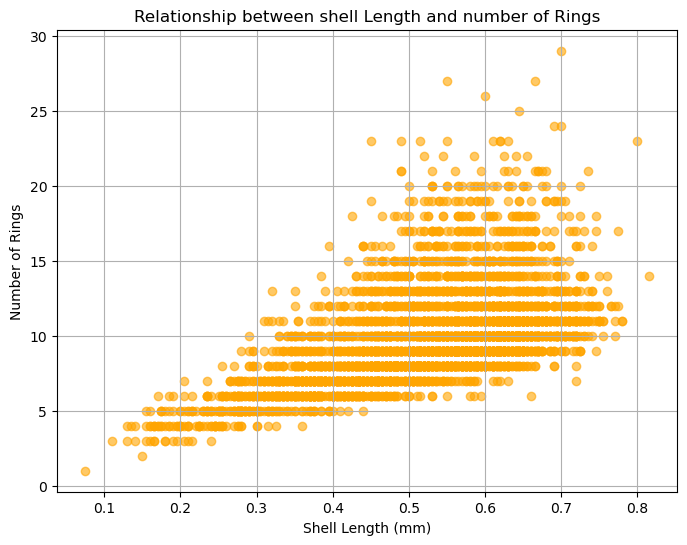

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(data["Length"], data["Rings"], alpha=0.6, color='orange')
plt.xlabel("Shell Length (mm)")
plt.ylabel("Number of Rings")
plt.title("Relationship between shell Length and number of Rings")
plt.grid(True)

plt.show()

A.1.2

            Length     Diameter       Height  Whole weight  Shucked weight  \
count  4177.000000  4177.000000  4177.000000   4177.000000     4177.000000   
mean      0.523992     0.407881     0.139516      0.828742        0.359367   
std       0.120093     0.099240     0.041827      0.490389        0.221963   
min       0.075000     0.055000     0.000000      0.002000        0.001000   
25%       0.450000     0.350000     0.115000      0.441500        0.186000   
50%       0.545000     0.425000     0.140000      0.799500        0.336000   
75%       0.615000     0.480000     0.165000      1.153000        0.502000   
max       0.815000     0.650000     1.130000      2.825500        1.488000   

       Viscera weight  Shell weight        Rings  
count     4177.000000   4177.000000  4177.000000  
mean         0.180594      0.238831     9.933684  
std          0.109614      0.139203     3.224169  
min          0.000500      0.001500     1.000000  
25%          0.093500      0.130000     8.

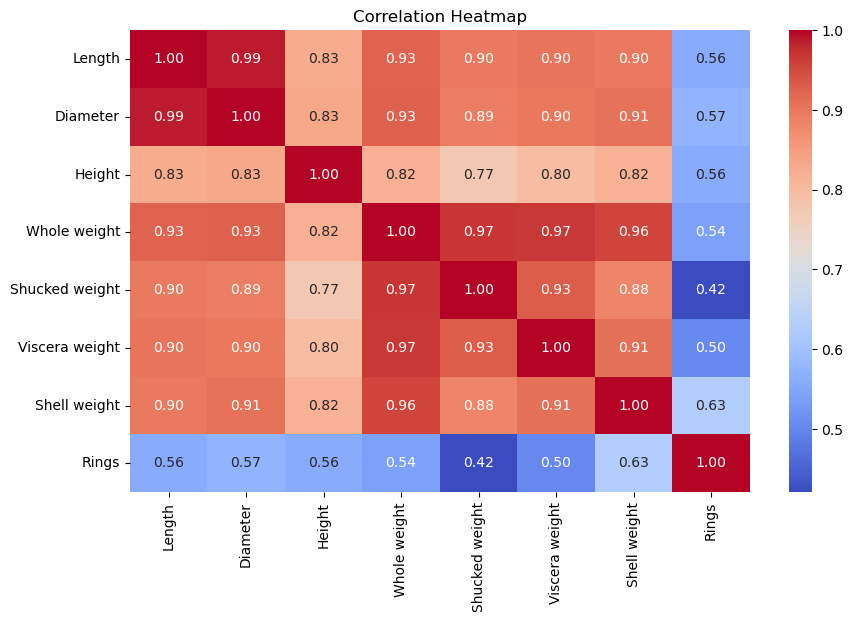

The feature that is the most correlated with rings is shell weight


In [15]:
print(data.describe())

correlation = data.corr(numeric_only = True)

plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()



Most_correlated_feature = "The feature that is the most correlated with rings is shell weight"
print(Most_correlated_feature)


A.1.3

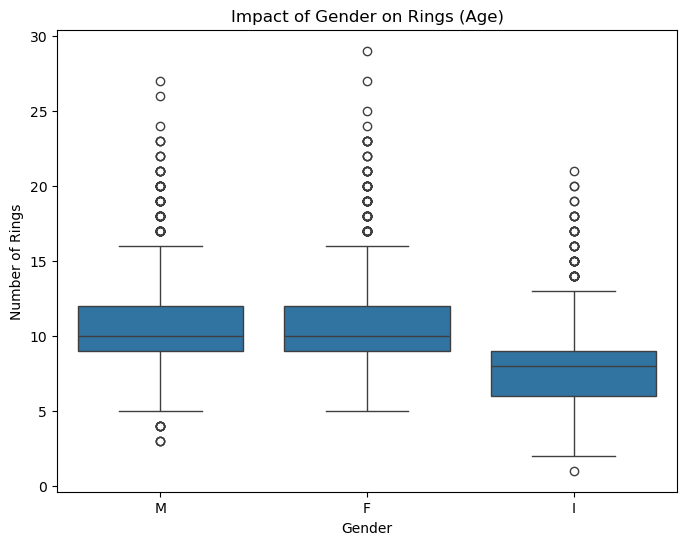

Gender does not appear to have an impact on rings as the males and females are very close and even have relatively the same outliers. The infants have, as expected, a lower number of rings overall.


In [16]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=data["Sex"], y=data["Rings"])
plt.xlabel("Gender")
plt.ylabel("Number of Rings")
plt.title("Impact of Gender on Rings (Age)")
plt.show()

Analyse = "Gender does not appear to have an impact on rings as the males and females are very close and even have relatively the same outliers. The infants have, as expected, a lower number of rings overall."
print(Analyse)

A.2.1

In [17]:
data = pd.get_dummies(data)
X = data.drop(columns="Rings", axis = 1) 
y = data["Rings"]

kbins = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile', subsample=None)
y = kbins.fit_transform(data[["Rings"]])


X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

def confirmation(y):
    y = np.array(y).flatten()
    print(y)
    proportion = pd.Series(y).value_counts(normalize = True )
    for bin, prop in proportion.items():
        print(f"Bin{int(bin)}: {prop:.2%}")

print("Confirmation training set:")
confirmation(y_train)
print("Confirmation validation set:")
confirmation(y_val)
print("Confirmation test set:")
confirmation(y_test)



Confirmation training set:
[3. 2. 4. ... 2. 3. 3.]
Bin3: 26.85%
Bin4: 22.99%
Bin1: 22.96%
Bin2: 16.49%
Bin0: 10.72%
Confirmation validation set:
[0. 0. 3. 4. 4. 1. 4. 1. 0. 1. 2. 2. 2. 2. 4. 3. 0. 3. 3. 1. 2. 3. 2. 2.
 3. 1. 3. 2. 0. 4. 3. 2. 3. 2. 2. 3. 1. 4. 2. 3. 4. 3. 4. 1. 2. 1. 1. 1.
 4. 4. 3. 2. 4. 1. 1. 3. 3. 3. 3. 4. 2. 1. 1. 4. 1. 4. 4. 2. 4. 1. 4. 1.
 1. 1. 3. 2. 3. 0. 0. 3. 0. 2. 0. 1. 3. 0. 0. 3. 4. 4. 1. 1. 3. 2. 1. 1.
 1. 4. 2. 3. 3. 2. 4. 1. 4. 1. 1. 4. 2. 0. 2. 4. 4. 1. 4. 1. 4. 1. 1. 3.
 0. 1. 2. 4. 1. 1. 4. 0. 1. 3. 2. 4. 2. 4. 3. 3. 1. 4. 2. 3. 2. 1. 4. 4.
 1. 1. 2. 3. 2. 4. 3. 0. 4. 0. 1. 3. 1. 4. 1. 1. 4. 1. 0. 1. 3. 2. 1. 3.
 2. 3. 2. 2. 3. 1. 1. 3. 3. 3. 3. 2. 3. 3. 0. 2. 4. 0. 0. 3. 4. 4. 1. 3.
 4. 3. 3. 3. 4. 4. 4. 3. 1. 4. 4. 2. 4. 4. 3. 2. 1. 3. 3. 4. 1. 1. 3. 3.
 1. 4. 2. 3. 2. 4. 1. 2. 3. 4. 2. 2. 3. 0. 2. 4. 4. 4. 4. 2. 3. 1. 4. 4.
 4. 3. 4. 3. 3. 3. 1. 2. 3. 4. 4. 3. 4. 2. 3. 2. 1. 0. 1. 2. 4. 1. 3. 4.
 3. 1. 1. 4. 4. 0. 2. 3. 3. 4. 3. 1. 3. 0. 1. 4. 4. 

A.2.2

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


r2_linear = r2_score(y_test, y_pred)
mse_linear = mean_squared_error(y_test, y_pred)
mae_linear = mean_absolute_error(y_test, y_pred)

print(f"Linear Regression R^2 Score: {r2_linear:.3f}")
print(f"Mean Squared Error: {mse_linear:.3f}")
print(f"Mean Absolute Error: {mae_linear:.3f}")
analysis = "The R2 is moderate but it can be better as now only around 50% of the variance is explained in the data and the mse and mae are high" 
print(analysis)

Linear Regression R^2 Score: 0.501
Mean Squared Error: 0.882
Mean Absolute Error: 0.743
The R2 is moderate but it can be better as now only around 50% of the variance is explained in the data and the mse and mae are high


A.2.3

In [19]:
val_scores = {}
for degree in range(2, 6):
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    y_val_pred = model.predict(X_val_poly)
    
    r2 = r2_score(y_val, y_val_pred)
    val_scores[degree] = r2
    print(f"Degree {degree}: R2 Score = {r2:.4f}")

best_degree = max(val_scores, key=val_scores.get)
print(f"Best degree based on validation R2: {best_degree}")



poly = PolynomialFeatures(degree=best_degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)
y_test_pred_poly = model.predict(X_test_poly)

r2_poly = r2_score(y_test, y_test_pred_poly)
mse_poly = mean_squared_error(y_test, y_test_pred_poly)
mae_poly = mean_absolute_error(y_test, y_test_pred_poly)

print(f"Test Results for Degree {best_degree}:")
print(f"R2: {r2_poly:.4f}, MSE: {mse_poly:.4f}, MAE: {mae_poly:.4f}")


Degree 2: R2 Score = 0.1811
Degree 3: R2 Score = -24.7416
Degree 4: R2 Score = -2301308.7635
Degree 5: R2 Score = -9812974184.3983
Best degree based on validation R2: 2
Test Results for Degree 2:
R2: 0.5579, MSE: 0.7813, MAE: 0.6827


A.2.4

In [20]:
k_values = [1, 3, 6, 10]
best_k = None
best_knn_r2 = -np.inf

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    y_val_pred = knn.predict(X_val)
    val_r2 = r2_score(y_val, y_val_pred)
    
    print(f"K = {k}: Validation R2 = {val_r2:.3f}")
    
    if val_r2 > best_knn_r2:
        best_knn_r2 = val_r2
        best_k = k

print(f"Best K for KNN: {best_k}")

knn = KNeighborsRegressor(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_test_pred_knn = knn.predict(X_test)
r2_knn = r2_score(y_test, y_test_pred_knn)
mse_knn = mean_squared_error(y_test, y_test_pred_knn)
mae_knn = mean_absolute_error(y_test, y_test_pred_knn)

print(f"Final KNN Regression:")
print(f"R2: {r2_knn:.4f}, MSE: {mse_knn:.4f}, MAE: {mae_knn:.4f}")

K = 1: Validation R2 = 0.280
K = 3: Validation R2 = 0.533
K = 6: Validation R2 = 0.586
K = 10: Validation R2 = 0.608
Best K for KNN: 10
Final KNN Regression:
R2: 0.5533, MSE: 0.7893, MAE: 0.6785


A.2.5

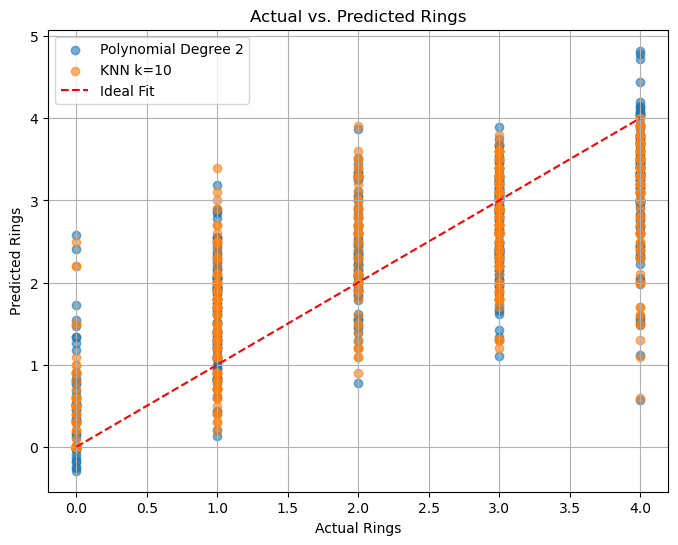

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred_poly, alpha=0.6, label=f'Polynomial Degree {best_degree}')
plt.scatter(y_test, y_test_pred_knn, alpha=0.6, label=f'KNN k={best_k}')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal Fit')
plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.title("Actual vs. Predicted Rings")
plt.legend()
plt.grid(True)
plt.show()


B.1.1

Fold 1: R2=0.6468, MSE=0.6482, MAE=0.6456
Fold 2: R2=0.4863, MSE=0.8655, MAE=0.6733
Fold 3: R2=0.5329, MSE=0.8487, MAE=0.7147
Fold 4: R2=0.5943, MSE=0.6978, MAE=0.6641
Fold 5: R2=0.6125, MSE=0.7250, MAE=0.6643
Fold 6: R2=0.5966, MSE=0.7226, MAE=0.6699
Fold 7: R2=-0.6036, MSE=2.8917, MAE=0.7532
Fold 8: R2=0.6116, MSE=0.7146, MAE=0.6669
Fold 9: R2=0.5921, MSE=0.6666, MAE=0.6400
Fold 10: R2=0.5904, MSE=0.6549, MAE=0.6341


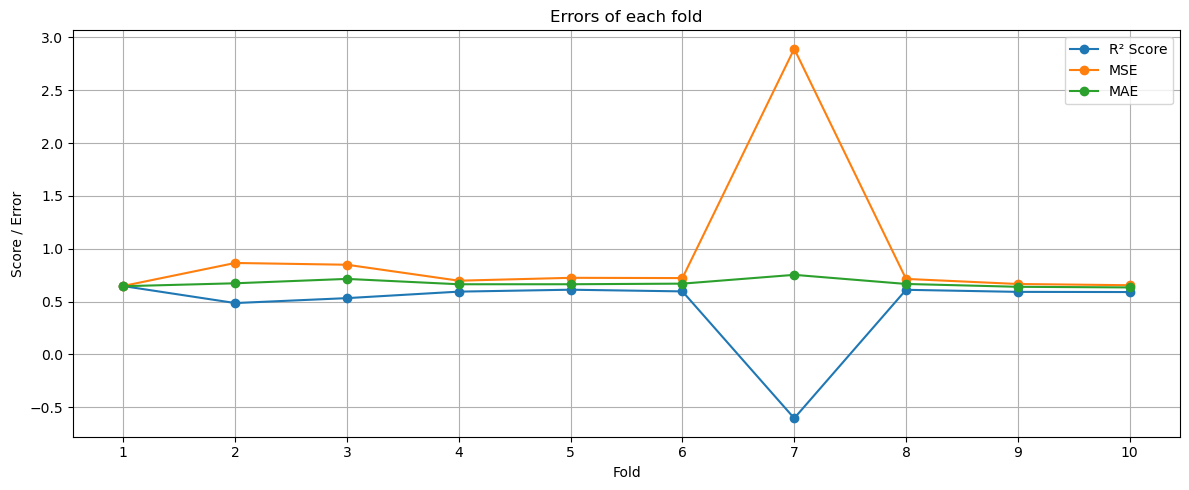

In [22]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
r2_scores, mse_scores, mae_scores = [], [], []

for fold, (train_index, test_index) in enumerate(kf.split(X)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index] 

    poly = PolynomialFeatures(degree=best_degree)
    X_train_fold_poly = poly.fit_transform(X_train_fold)
    X_test_fold_poly = poly.transform(X_test_fold)

    model = LinearRegression()
    model.fit(X_train_fold_poly, y_train_fold)
    y_pred_fold = model.predict(X_test_fold_poly)

    r2_scores.append(r2_score(y_test_fold, y_pred_fold))
    mse_scores.append(mean_squared_error(y_test_fold, y_pred_fold))
    mae_scores.append(mean_absolute_error(y_test_fold, y_pred_fold))

    print(f"Fold {fold+1}: R2={r2_scores[-1]:.4f}, MSE={mse_scores[-1]:.4f}, MAE={mae_scores[-1]:.4f}")


folds = list(range(1, 11))
plt.figure(figsize=(12, 5))
plt.plot(folds, r2_scores, marker='o', label='R² Score')
plt.plot(folds, mse_scores, marker='o', label='MSE')
plt.plot(folds, mae_scores, marker='o', label='MAE')
plt.title("Errors of each fold")
plt.xlabel("Fold")
plt.xticks(folds)
plt.ylabel("Score / Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


B.1.2

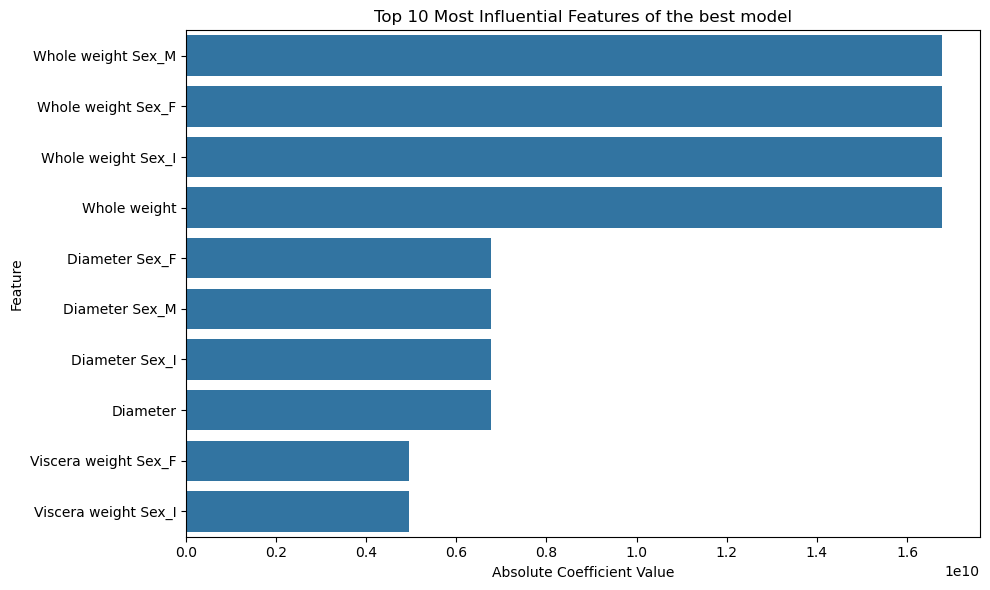

In [23]:
feature_names = poly.get_feature_names_out(X.columns)
importance = model.coef_ 

importance = np.ravel(importance)

importance_data = pd.DataFrame({ "Feature": feature_names, "Coefficient": importance})

importance_data["Absolute Coefficient"] = importance_data["Coefficient"].abs()
top_features = importance_data.sort_values(by="Absolute Coefficient", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="Absolute Coefficient", y="Feature", data=top_features)
plt.title("Top 10 Most Influential Features of the best model")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


B.2.1

In [24]:
worst_fold = mse_scores.index(max(mse_scores))
print(f"Worst-performing fold index (by MSE): {worst_fold}")


Worst-performing fold index (by MSE): 6


B.2.2

<Figure size 800x500 with 0 Axes>

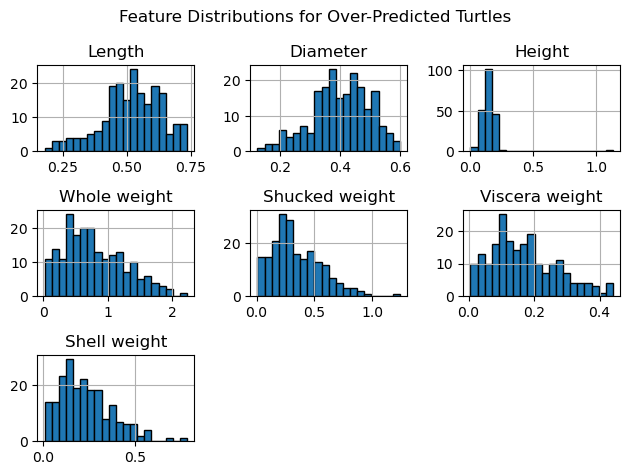

In [26]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    if fold == worst_fold:
        X_train_worstfold, X_test_worstfold = X.iloc[train_index], X.iloc[test_index]
        y_train_worstfold, y_test_worstfold = y[train_index], y[test_index]
        poly = PolynomialFeatures(degree=best_degree)
        X_train_poly = poly.fit_transform(X_train_worstfold)
        X_test_poly = poly.transform(X_test_worstfold)
        model = LinearRegression()
        model.fit(X_train_poly, y_train_worstfold)
        y_pred_worstfold = model.predict(X_test_poly)
        break

overpredicted = y_pred_worstfold > y_test_worstfold
overpredicted_data = X_test_worstfold[overpredicted]

plt.figure(figsize=(8,5))
overpredicted_data.hist(bins=20, edgecolor='black')
plt.suptitle("Feature Distributions for Over-Predicted Turtles")
plt.tight_layout()
plt.show()



Patterns:
Lenght and diameter have a strong left skew and all of the weight features show a quite strong right skew. As for the hight where almost all of the overpredicted values were more near the 0.0. 

So, most over-predicted turtles have lower weights and smaller height, even though a few high-weight outliers exist.
This suggests the model tends to overestimate age for smaller, lighter turtles, possibly due to skewed training data or overfitting to heavier turt;es

B.2.3

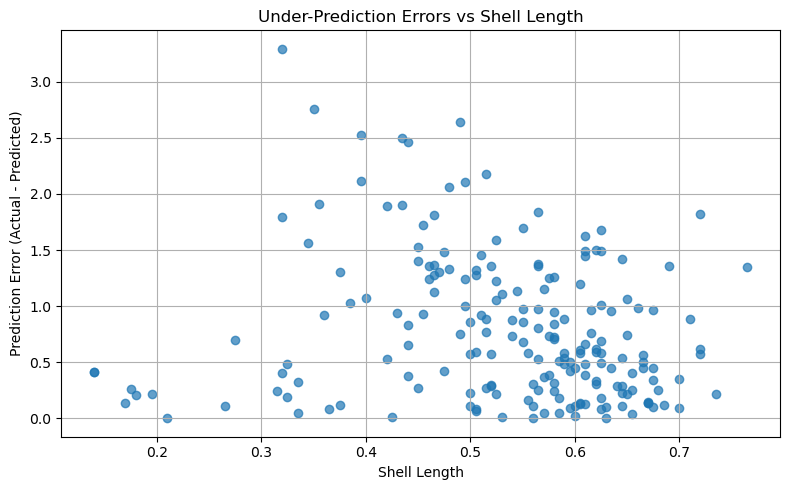

In [27]:
overpredicted_overall = y_pred < y_test
overpredicted_overall_data = X_test[overpredicted_overall]
errors = (y_test - y_pred)[overpredicted_overall]

plt.figure(figsize=(8,5))
plt.scatter(overpredicted_overall_data["Length"], errors, alpha=0.7)
plt.xlabel("Shell Length")
plt.ylabel("Prediction Error (Actual - Predicted)")
plt.title("Under-Prediction Errors vs Shell Length")
plt.grid(True)
plt.tight_layout()
plt.show()


B.3.1

In [29]:
summary_df = pd.DataFrame([
    {"Model": "Linear Regression", "Hyperparameters": "NA", "R2": r2_linear, "MSE": mse_linear, "MAE": mae_linear},
    {"Model": f"Polynomial Regression (deg={best_degree})", "Hyperparameters": f"deg={best_degree}", "R2": r2_poly, "MSE": mse_poly, "MAE": mae_poly},
    {"Model": f"KNN Regression (k={best_k})", "Hyperparameters": f"k={best_k}", "R2": r2_knn, "MSE": mse_knn, "MAE": mae_knn}
])

print(summary_df)


                           Model Hyperparameters        R2       MSE       MAE
0              Linear Regression              NA  0.500883  0.882039  0.742565
1  Polynomial Regression (deg=2)           deg=2  0.557898  0.781282  0.682731
2          KNN Regression (k=10)            k=10  0.553344  0.789330  0.678469


B.3.2

In [31]:
summary_df.to_csv("turtle_model_summary.csv", index=False)